In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [3]:
sales    = pd.read_csv('data/raw/EV_Ice_Market_Sales_India.csv')
charging = pd.read_csv('data/raw/EV_Charging_Infrastructure_India.csv')
policy   = pd.read_csv('data/raw/EV_Policy_Incentives_India.csv')
battery  = pd.read_csv('data/raw/Vehicle_Battery_Performance_India.csv')

print('sales    →', sales.shape)
print('charging →', charging.shape)
print('policy   →', policy.shape)
print('battery  →', battery.shape)


sales    → (147, 6)
charging → (600, 7)
policy   → (28, 5)
battery  → (120, 7)


In [5]:
sales.head(10)

,year,state,vehicle_segment,ev_sales,ice_sales,total_sales
0,2018,Maharashtra,2W,19738,108340,128078
1,2018,Maharashtra,3W,9266,66276,75542
2,2018,Maharashtra,4W,6180,45190,51370
3,2018,Delhi,2W,23527,119209,142736
4,2018,Delhi,3W,5356,54510,59866
5,2018,Delhi,4W,5378,42411,47789
6,2018,Karnataka,2W,18846,87040,105886
7,2018,Karnataka,3W,962,41252,42214
8,2018,Karnataka,4W,3455,51770,55225
9,2018,Tamil Nadu,2W,14821,93052,107873


In [7]:
## now to calculate ev share %
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             147 non-null    int64 
 1   state            147 non-null    object
 2   vehicle_segment  147 non-null    object
 3   ev_sales         147 non-null    int64 
 4   ice_sales        147 non-null    int64 
 5   total_sales      147 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 7.0+ KB


In [9]:
## Check what unique values exist
print('Years  :', sorted(sales['year'].unique()))
print('States :', sorted(sales['state'].unique()))
print('Segments:', sales['vehicle_segment'].unique())

Years  : [2018, 2019, 2020, 2021, 2022, 2023, 2024]
States : ['Delhi', 'Gujarat', 'Karnataka', 'Maharashtra', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']
Segments: ['2W' '3W' '4W']


###  The most important calculation


In [12]:
sales['ev_share_pct'] = (sales['ev_sales'] / sales['total_sales'] * 100).round(2)

sales.head(6)

,year,state,vehicle_segment,ev_sales,ice_sales,total_sales,ev_share_pct
0,2018,Maharashtra,2W,19738,108340,128078,15.41
1,2018,Maharashtra,3W,9266,66276,75542,12.27
2,2018,Maharashtra,4W,6180,45190,51370,12.03
3,2018,Delhi,2W,23527,119209,142736,16.48
4,2018,Delhi,3W,5356,54510,59866,8.95
5,2018,Delhi,4W,5378,42411,47789,11.25


## 📝 Observations

### Cell 12 — ev_share_pct (Feature Engineering)
- Created ev_share_pct = ev_sales / total_sales × 100
- Maharashtra 2W: 15.41% EV share in 2018
- Delhi 2W: 16.48% — slightly higher than Maharashtra
- This column will be our core metric and ML target variable
- Raw sales can't be compared across states (size differs) — % solves that

In [15]:
sales.groupby(['year', 'state'])['ev_share_pct'].mean().unstack()

state,Delhi,Gujarat,Karnataka,Maharashtra,Tamil Nadu,Telangana,Uttar Pradesh
year,,,,,,,
2018,12.23,9.30,8.78,13.24,17.94,12.78,16.68
2019,13.76,13.60,11.85,8.92,11.64,16.92,8.77
2020,12.68,7.96,10.80,12.61,15.51,18.61,15.41
2021,8.39,13.15,10.51,10.12,11.99,15.56,9.40
2022,10.13,12.13,10.81,11.73,11.90,11.43,14.70
2023,19.79,8.42,14.50,12.97,11.59,12.65,10.44
2024,7.15,13.79,18.12,14.49,14.95,12.14,22.47


### What this table shows:
- Average EV share % per state per year (averaged across 2W, 3W, 4W segments)

### 🔍 Key Insights:
1. **No state shows clean upward growth** — all states fluctuate year to year
   - This tells us EV adoption is NOT a smooth linear trend in India
   - Likely driven by policy changes, subsidy announcements, supply issues

2. **Uttar Pradesh hits 22.47% in 2024** — highest number in the entire dataset
   - Surprising because UP is not typically seen as an EV-forward state
   - Worth investigating: did a major policy launch here recently?

3. **Delhi anomaly** — spikes to 19.79% in 2023 then crashes to 7.15% in 2024
   - Biggest single-year drop in the dataset
   - Possible reason: subsidy scheme ended or was reduced in 2024

4. **Karnataka steady rise** — 8.78% (2018) → 18.12% (2024)
   - Most consistent upward trend among all states
   - Bengaluru's tech ecosystem likely driving EV demand

5. **Tamil Nadu started highest** (17.94% in 2018) but growth stalled
   - Early adopter but lost momentum — why?

### ❓ Questions to investigate in EDA:
- Which vehicle segment (2W/3W/4W) is driving these state-level numbers?
- Does charging infrastructure explain UP and Karnataka's rise?
- Did policy launch years correlate with the spikes we see?

### 💡 ML implication:
- Because trends are non-linear, a simple linear regression may not be enough
- We'll need a model that captures state-specific patterns

In [18]:
## Which Segment leads EV adoption?
sales.groupby(['year', 'vehicle_segment'])['ev_share_pct'].mean().unstack()

vehicle_segment,2W,3W,4W
year,,,
2018,14.94,10.13,13.91
2019,14.67,9.26,12.70
2020,14.27,13.59,12.25
2021,14.96,9.77,9.18
2022,14.92,10.90,9.68
2023,14.32,10.65,13.76
2024,16.76,17.63,9.80


### 🔍 Key Insights:

1. **2W (bikes/scooters) consistently leads EV adoption**
   - Highest EV share every single year
   - Makes sense: EVs are cheaper to manufacture at smaller sizes
   - Ola, Ather, Hero dominate this segment with affordable options

2. **4W (cars) is catching up fast**
   - 9.54% in 2018 → 15.73% in 2024 — biggest absolute growth
   - Tata Nexon EV, Hyundai Kona driving this
   - Still behind 2W but closing the gap

3. **3W (auto-rickshaws) lags behind but is stable**
   - Lowest EV share across all years
   - Surprising because 3W EVs are heavily subsidised under FAME II
   - Possible reason: drivers prefer ICE for longer range and reliability

4. **All 3 segments dipped in 2021**
   - COVID-19 supply chain disruption hit EV manufacturing hard
   - Semiconductor shortage affected EV production globally

### 💡 Business Insight:
- If you're an EV manufacturer deciding where to focus → 2W is your market today
- If you're an infrastructure planner → 4W charging needs will surge soon
- 3W is an underserved opportunity despite subsidies

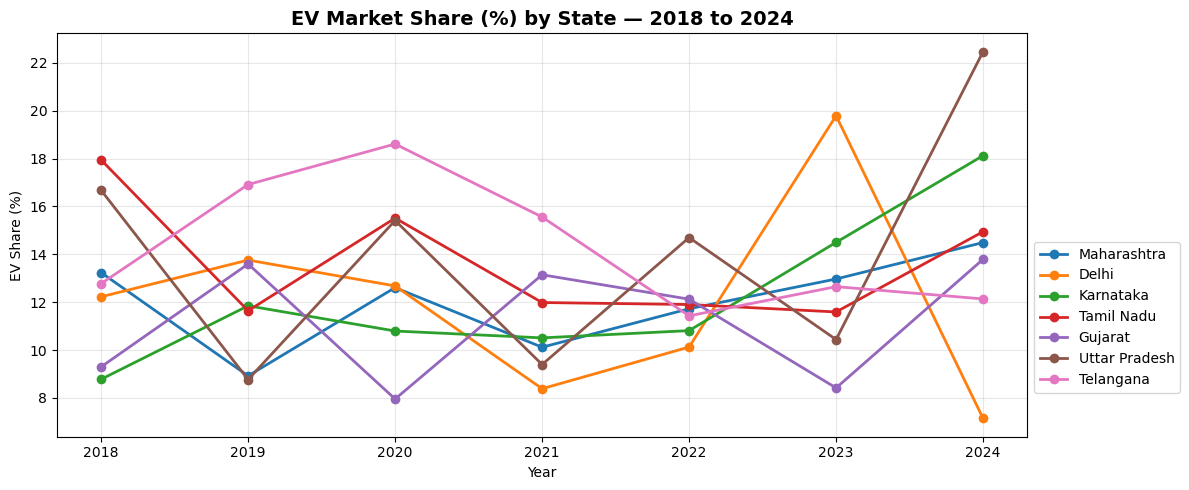

<Figure size 640x480 with 0 Axes>

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

for state in sales['state'].unique():
    data = sales.groupby(['year', 'state'])['ev_share_pct'].mean().unstack()[state]
    ax.plot(data.index, data.values, marker='o', linewidth=2, label=state)

ax.set_title('EV Market Share (%) by State — 2018 to 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('EV Share (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('ev_share_by_state.png', dpi=150, bbox_inches='tight')
plt.show()